In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("ToyotaCorolla - MLR.csv")
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [4]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

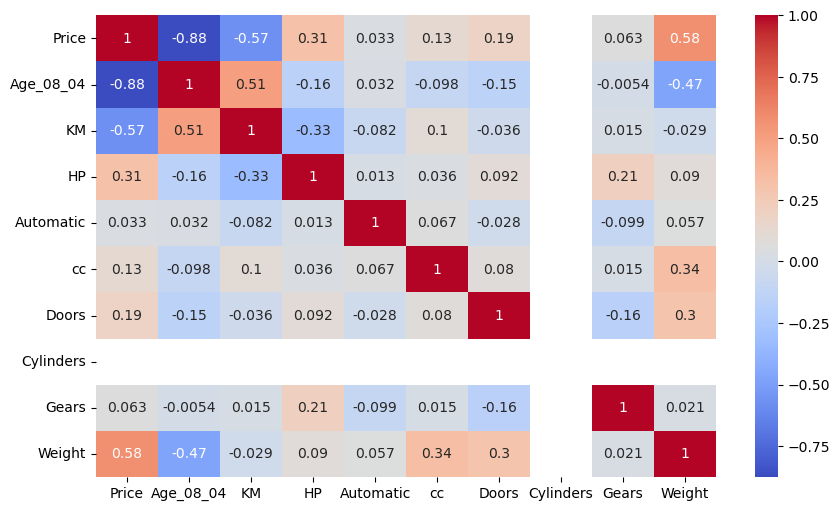

In [5]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

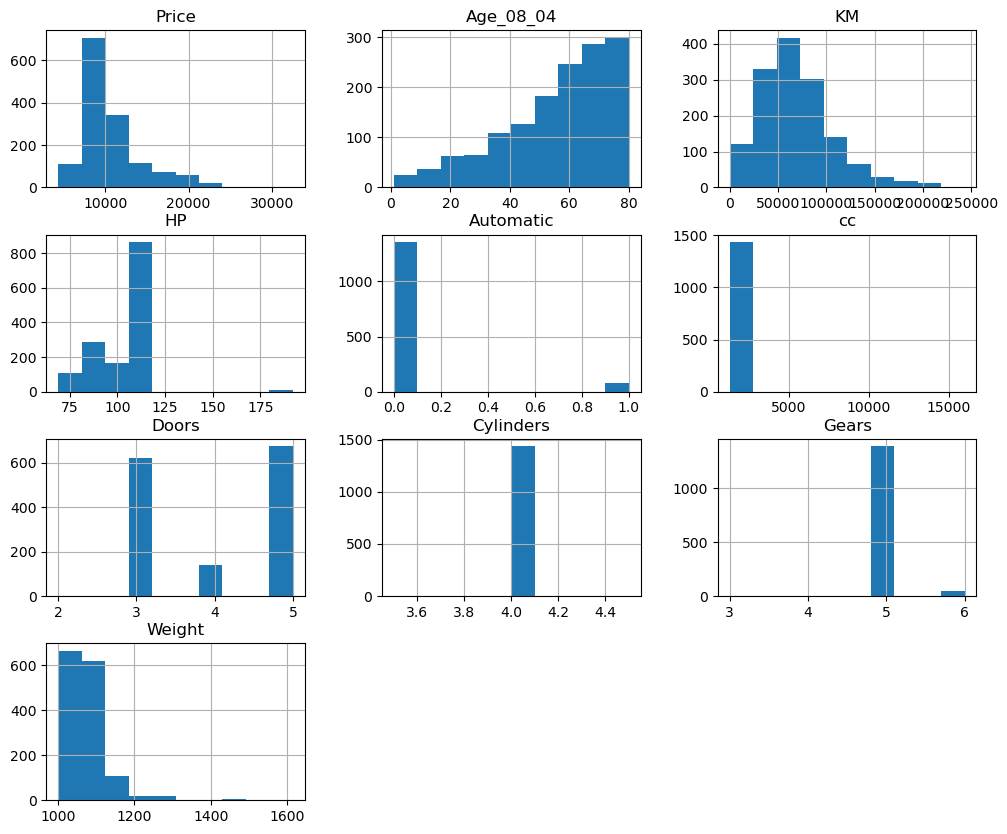

In [6]:
df.hist(figsize=(12,10))
plt.show()

EDA Observations:

• Price has strong negative correlation with Age (-0.88).
• Price has moderate negative correlation with KM.
• Price has positive correlation with Weight and HP.
• Most variables show skewed distribution.
• Dataset has no missing values.

Hence, the dataset is suitable for Multiple Linear Regression.

In [7]:
#Convert Fuel_Type (Categorical)
df = pd.get_dummies(df, columns=["Fuel_Type"], drop_first=True)
df.head()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986,90,0,2000,3,4,5,1165,True,False
1,13750,23,72937,90,0,2000,3,4,5,1165,True,False
2,13950,24,41711,90,0,2000,3,4,5,1165,True,False
3,14950,26,48000,90,0,2000,3,4,5,1165,True,False
4,13750,30,38500,90,0,2000,3,4,5,1170,True,False


In [11]:
#Define X and y
X = df.drop("Price", axis=1)
y = df["Price"]

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("R2:", r2_score(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

R2: 0.8348888040611082
MAE: 990.8872739193923
RMSE: 1484.2654153296512


Model 1 (Linear Regression) Results:

• R² score is 0.835 which indicates good prediction performance.
• MAE and RMSE values show acceptable prediction error.
• Age, KM and Weight appear to influence price strongly.

Hence, Linear Regression performs well on this dataset.

In [14]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

print("R2:", r2_score(y_test, y_pred_ridge))
print("MAE:", mean_absolute_error(y_test, y_pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))

R2: 0.8351359377712335
MAE: 990.7338342026006
RMSE: 1483.1541963778884


Model 2 (Ridge Regression) Results:

• Ridge regression produced similar R² score as linear regression.
• Slight improvement in MAE and RMSE was observed.
• Ridge helps reduce overfitting by controlling large coefficients.

Hence, Ridge performs slightly better than simple linear regression.

In [16]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

print("R2:", r2_score(y_test, y_pred_lasso))
print("MAE:", mean_absolute_error(y_test, y_pred_lasso))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))

R2: 0.8349467801805
MAE: 990.8940127223725
RMSE: 1484.0048045827489


Model 3 (Lasso Regression) Results:

• Lasso regression produced similar R² score.
• Very small difference in MAE and RMSE was observed.
• Lasso helps in feature selection by shrinking less important coefficients.

Hence, all models perform similarly on this dataset.

Final Conclusion:

Multiple Linear Regression was used to predict car prices based on different attributes.

EDA showed strong relationships between Price and Age, KM, HP, and Weight.

Among the models:
• Linear Regression performed well.
• Ridge slightly reduced error.
• Lasso helped in feature selection.

Overall, Ridge performed slightly better, but all models gave similar performance.

Interview Answers

1. Normalization scales data between 0 and 1, while Standardization transforms data to mean 0 and standard deviation 1. These help models perform better by keeping features on similar scale.

2. Multicollinearity can be handled by removing correlated features, using Ridge or Lasso regression, or applying PCA.